# 📊 Notebook 01 : Analyse Exploratoire des Données (EDA) & Diagnostic Qualité

## 🎯 Objectif du Notebook
Dans un projet d'apprentissage automatique appliqué à la santé, l'Analyse Exploratoire des Données (*Exploratory Data Analysis* - **EDA**) constitue l'étape fondamentale avant toute modélisation. Ce notebook vise à :
1. **Comprendre la structure clinique du dataset** : examiner les variables médicales, leurs unités de mesure et la distribution de la variable cible (`Outcome`).
2. **Auditer la qualité des données (Détection des anomalies)** : identifier une problématique majeure fréquente en données de santé : la présence de **valeurs manquantes masquées sous forme de zéros (`0`)**.
3. **Évaluer les associations cliniques** : analyser les corrélations statistiques entre les biomarqueurs (comme le glucose ou l'indice de masse corporelle) et le diagnostic du diabète.

---

## 1. Initialisation de l'Environnement et Chargement des Données
Nous commençons par importer les bibliothèques d'analyse (`pandas`, `numpy`, `matplotlib`, `seaborn`) et charger le jeu de données brut (`Pima Indians Diabetes Database`).


In [15]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data_loader import load_raw_data

In [16]:
df = load_raw_data()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 💡 Inspection des premières observations (`df.head()`)
Chaque ligne du tableau correspond aux données cliniques d'une patiente unique. Voici la signification médicale et les unités de mesure de chaque variable :

* **`Pregnancies`** : Nombre de grossesses vécues par la patiente.
* **`Glucose`** : Concentration de glucose plasmatique à 2 heures lors d'une épreuve d'hyperglycémie orale ($mg/dL$). Un taux élevé est l'indicateur principal du diabète.
* **`BloodPressure`** : Pression artérielle diastolique ($mm~Hg$).
* **`SkinThickness`** : Épaisseur du pli cutané tricipital ($mm$), un indicateur d'évaluation de la masse adipeuse corporelle.
* **`Insulin`** : Taux d'insuline sérique à 2 heures ($\mu U/mL$).
* **`BMI`** : Indice de Masse Corporelle ($poids / taille^2$, en $kg/m^2$).
* **`DiabetesPedigreeFunction`** : Fonction de prédisposition génétique évaluant l'historique familial de diabète.
* **`Age`** : Âge de la patiente en années ($\ge 21$ ans).
* **`Outcome`** : **Variable cible diagnostique** $ightarrow$ `0` = Patiente non-diabétique, `1` = Patiente diabétique.

> [!WARNING]
> **Observation immédiate d'anomalies cliniques** :  
> Dès les premières lignes du tableau, on observe que les patientes `0` et `1` présentent une valeur `Insulin = 0`, et que la patiente `2` affiche à la fois `SkinThickness = 0` et `Insulin = 0`. D'un point de vue biologique, un être humain ne peut pas avoir une épaisseur cutanée ou une insuline rigoureusement égale à zéro. Ces observations indiquent la présence de **valeurs manquantes non déclarées**.

---

## 2. Audit de la Structure et des Types (`df.info()`)


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 💡 Interprétation de `df.info()`
La méthode `df.info()` indique que le jeu de données comporte **768 observations** et que la colonne `Non-Null Count` affiche `768 non-null` pour les 9 variables. 

> [!NOTE]
> **Le piège des zéros en pandas** :  
> À première vue, la bibliothèque `pandas` ne détecte aucune valeur manquante (`NaN` / *Not a Number*). Cependant, comme nous l'avons repéré dans les premières lignes, les valeurs manquantes ont été enregistrées sous forme de chiffres `0` lors de la collecte des données. Pour le système informatique, le chiffre `0` est une valeur numérique valide, d'où l'absence d'alerte automatique.
> 
> Pour vérifier la plausibilité biologique de ces chiffres, nous devons analyser les statistiques descriptives complètes avec `df.describe()`.

---

## 3. Analyse Statistique Descriptive et Définition de la Problématique (`df.describe()`)


In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 💡 Interprétation des Statistiques Descriptives
L'analyse de la ligne **`min`** (valeur minimale observée) confirme formellement l'anomalie : cinq variables vitales présentent un minimum rigoureusement égal à `0.000000` :
- **`Glucose`** (minimum = `0`)
- **`BloodPressure`** (minimum = `0`)
- **`SkinThickness`** (minimum = `0`)
- **`Insulin`** (minimum = `0`)
- **`BMI`** (minimum = `0`)

D'un point de vue clinique, une pression artérielle de $0~mm~Hg$ ou un Indice de Masse Corporelle de $0~kg/m^2$ sont incompatibles avec la vie. Il est donc avéré que **ces zéros représentent en réalité des données médicales manquantes (*Masked Missing Values*)**.

Quantifions précisément le volume et le pourcentage d'observations impactées par ces valeurs erronées.


In [7]:
cols_a_corriger = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_a_corriger:
    nb_zeros = (df[col] == 0).sum()
    pourcentage = nb_zeros / len(df) * 100
    print(f'{col:25s} : {nb_zeros:3d} zéros ({pourcentage:.1f}%)')

Glucose                   :   5 zéros (0.7%)
BloodPressure             :  35 zéros (4.6%)
SkinThickness             : 227 zéros (29.6%)
Insulin                   : 374 zéros (48.7%)
BMI                       :  11 zéros (1.4%)


### 💡 Diagnostic et Quantification des Zéros Masqués
Le tableau ci-dessus révèle la proportion exacte de mesures manquantes :

* **`Insulin` (48,70 % de zéros)** : Près de la moitié des examens d'insuline sont manquants. Supprimer les lignes correspondantes entraînerait la perte de 50 % du jeu de données, ce qui réduirait considérablement la capacité d'apprentissage du modèle.
* **`SkinThickness` (29,56 % de zéros)** : Près d'un tiers des mesures du pli cutané font défaut.
* **`BloodPressure` (4,56 %)**, **`BMI` (1,43 %)** et **`Glucose` (0,65 %)** : Proportions plus faibles, mais critiques (en particulier pour le glucose et l'IMC, qui sont des biomarqueurs majeurs).

> [!IMPORTANT]
> **Décision méthodologique pour l'étape de prétraitement (`02_preprocessing.ipynb`)** :  
> 1. **Ne pas supprimer les lignes** : Une suppression des patients avec des valeurs à zéro amputerait la moitié du jeu de données et induirait un biais de sélection.  
> 2. **Remplacer par `np.nan`** : Ces zéros devront d'abord être convertis explicitement en valeurs manquantes (`NaN`).  
> 3. **Imputation par la Médiane** : Nous appliquerons une imputation par la **médiane** (sensiblement plus robuste aux valeurs extrêmes que la moyenne) calculée **strictement sur le jeu d'apprentissage (`X_train`)** afin de prévenir tout phénomène de *Data Leakage* (fuite d'information du jeu de test vers le modèle).

---

## 4. Visualisation des Distributions (`df.hist()`)


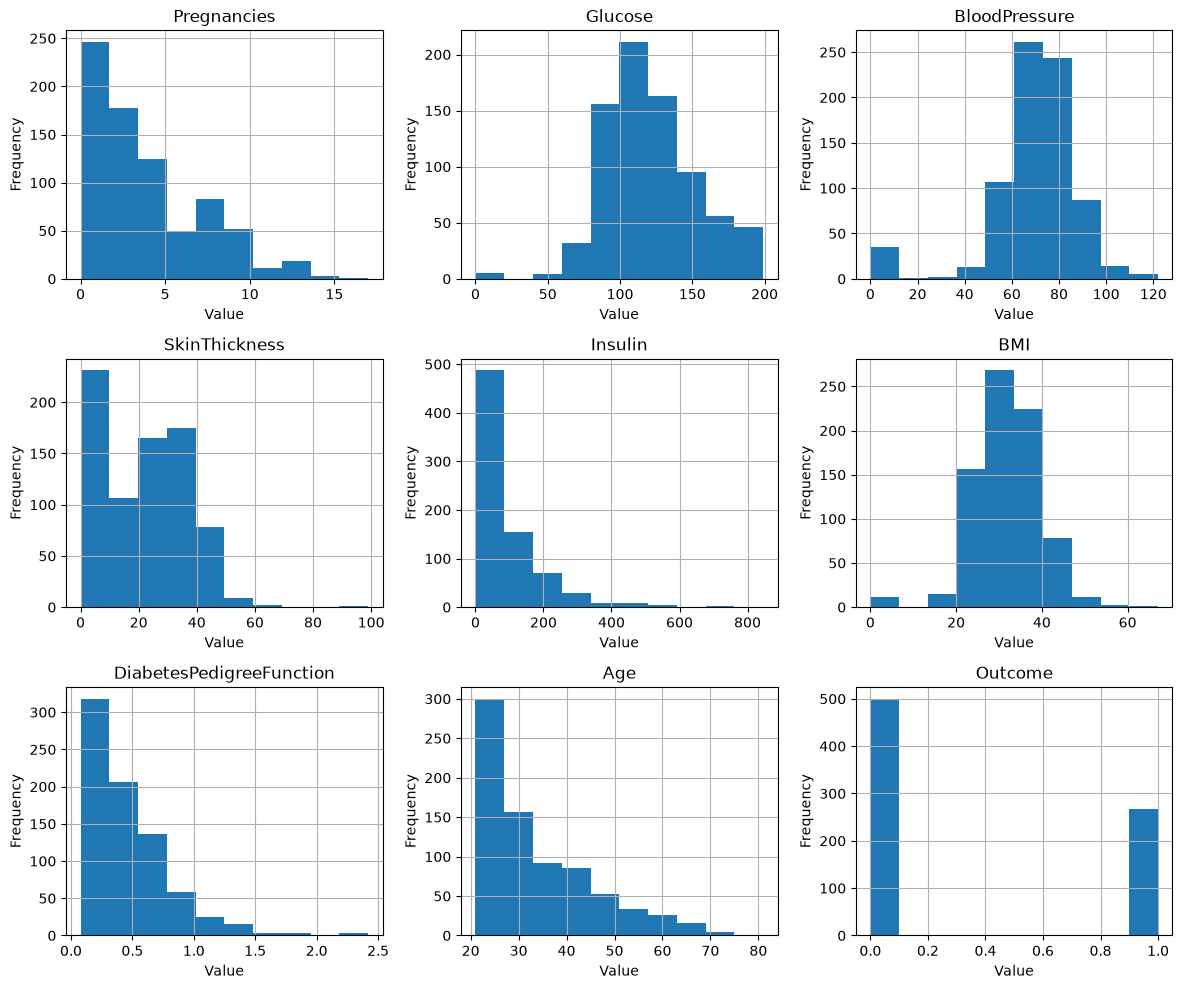

In [10]:
graphs = df.hist(figsize=(12, 10))
for graph in graphs.flatten():
    graph.set_xlabel('Value')
    graph.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 💡 Analyse Visuelle des Distributions (Histogrammes)
Les histogrammes illustrent la répartition des valeurs pour chaque paramètre clinique :

1. **Visualisation directe du pic de zéros** : Sur les graphiques de l'**`Insulin`** et de **`SkinThickness`**, on distingue nettement une barre verticale disproportionnée collée à la valeur `0`. Cela illustre physiquement les 48,7 % et 29,6 % de valeurs manquantes identifiées ci-dessus.
2. **Asymétrie positive (*Right-skewed distributions*)** : Les distributions de l'`Insulin`, de l'`Age` et de `DiabetesPedigreeFunction` s'étalent vers la droite avec une longue queue (*long tail*) due à la présence de valeurs extrêmes élevées (par exemple un pic d'insuline atteignant $846~\mu U/mL$). Cette asymétrie justifie l'utilisation de la **médiane** plutôt que de la moyenne générale pour l'imputation future.

---

## 5. Matrice de Corrélation et Facteurs de Risque (`df.corr()`)


In [11]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


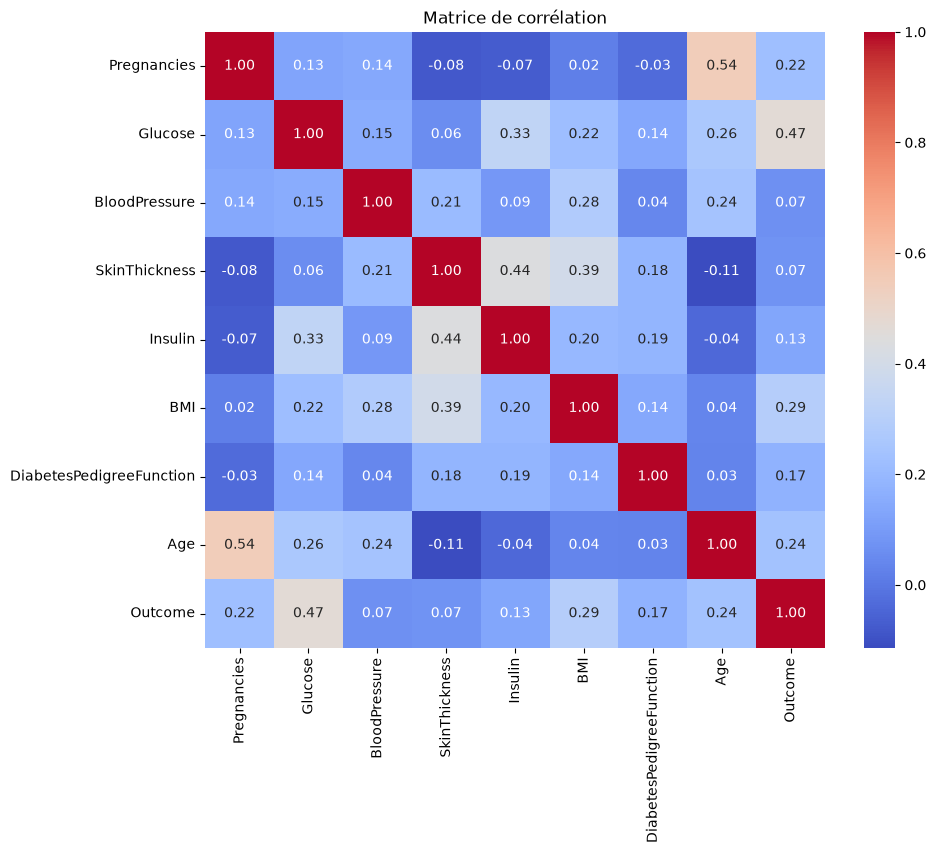

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

### 💡 Interprétation Clinique de la Matrice de Corrélation
La matrice de corrélation (calculée via le coefficient linéaire de Pearson, variant de `-1.0` à `+1.0`) permet de hiérarchiser les variables les plus fortement associées au diagnostic `Outcome` :

* **`Glucose` ($r = 0.47$)** : Affiche la corrélation positive la plus élevée avec la présence de la maladie. D'un point de vue médical, l'hyperglycémie chronique constitue le critère biologique cardinal du diabète, ce qui confirme la cohérence clinique de notre jeu de données.
* **`BMI` ($r = 0.29$) et `Age` ($r = 0.24$)** : Constituent les deuxième et troisième facteurs cliniques les plus corrélés au risque. Le surpoids/obésité et le vieillissement corporel sont des facteurs de prédisposition majeurs bien documentés en endocrinologie.
* **`Pregnancies` ($r = 0.22$) et `DiabetesPedigreeFunction` ($r = 0.17$)** : Montrent un impact modéré, reflétant l'influence de l'historique gestationnel et du patrimoine génétique.

---

## 6. Analyse Discriminante Croisée par Classe (`sns.boxplot()`)


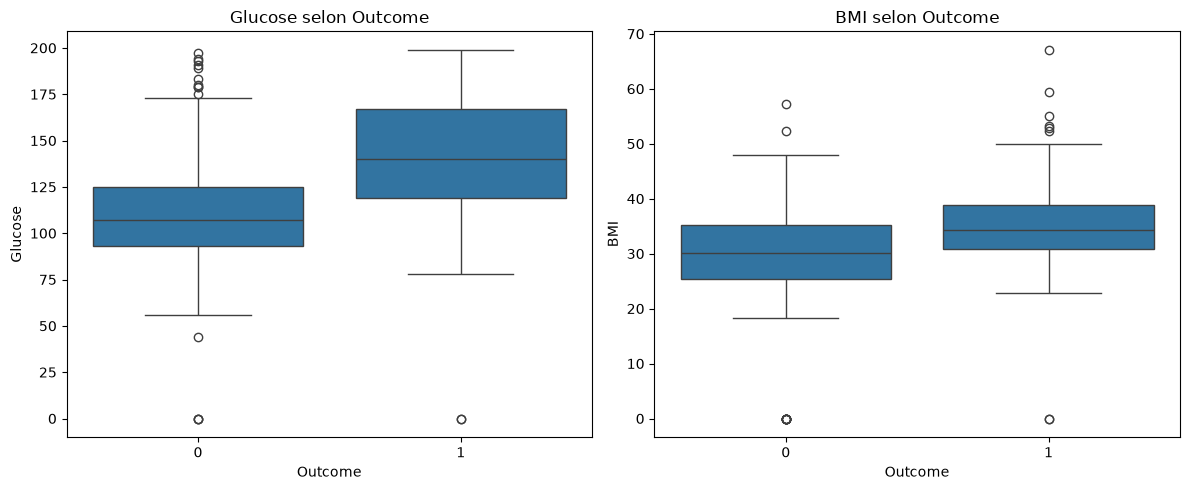

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[0])
axes[0].set_title('Glucose selon Outcome')

sns.boxplot(data=df, x='Outcome', y='BMI', ax=axes[1])
axes[1].set_title('BMI selon Outcome')

plt.tight_layout()
plt.show()

### 💡 Interprétation Comparative (Patients Sains vs Diabétiques)
Les boîtes à moustaches (*Boxplots*) comparent directement la médiane (ligne centrale de la boîte) et la dispersion (écart interquartile) des variables clés entre le groupe non-diabétique (`Outcome = 0`, en bleu) et le groupe diabétique (`Outcome = 1`, en orange) :

1. **Séparation nette sur le `Glucose`** : La boîte des patientes diabétiques est positionnée nettement au-dessus de celle des patientes saines. La médiane de glucose passe d'environ **$110~mg/dL$** chez les personnes saines à près de **$140~mg/dL$** chez les personnes malades. Le faible chevauchement entre les deux distributions confirme que le glucose sera la variable de discrimination la plus puissante pour nos futurs modèles.
2. **Élévation notable du `BMI`** : L'Indice de Masse Corporelle médian est également plus élevé chez les patientes diabétiques (autour de **$34~kg/m^2$**) par rapport au groupe sain (autour de **$30~kg/m^2$**). Bien que les distributions se chevauchent davantage que pour le glucose, l'obésité apparaît clairement comme un co-facteur aggravant.
3. **Observation des points extrêmes (*Outliers*)** : Sur chaque graphique, on note la présence de points isolés sur la ligne `0`. Il s'agit des zéros masqués non encore corrigés à cette étape du pipeline, qui feront l'objet d'un traitement rigoureux dans le notebook **`02_preprocessing.ipynb`**.

---

## 📋 Synthèse et Conclusion de l'Étape 01
Au terme de cette Analyse Exploratoire des Données :
- Nous avons identifié un facteur clinique prédominant (**`Glucose`**) et deux co-facteurs majeurs (**`BMI`**, **`Age`**).
- Nous avons posé le diagnostic technique d'une corruption de données importante : **près de 49 % des mesures d'insuline et 30 % des mesures de pli cutané sont absentes (`0`)**.
- Le notebook suivant (`02_preprocessing.ipynb`) mettra en œuvre une stratégie de nettoyage et de prétraitement sans *Data Leakage* pour préparer un jeu de données sain à l'apprentissage automatique.
